## Module_3: *(Template)*

## Team Members:
*(Fill in)*

## Project Title:
*(Fill in)*


## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analysis

We analyze 79 binary mask images of lung tissue (specimen SK658) acquired at depths from 15–10,000 μm. Each image is thresholded and the percentage of white pixels (fibrosis/collagen indicator) is computed. We first evaluate linear interpolation accuracy against ground-truth images, then build a Ridge-regularized polynomial regression model to better capture the depth–fibrosis relationship.

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def analyze_image(filepath):
    """Load grayscale image, threshold to binary, return (white, black, white_pct)."""
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load: {filepath}")
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    white = int(np.sum(binary == 255))
    black = int(np.sum(binary == 0))
    return white, black, 100.0 * white / (white + black)

### Interpolation

Using 6 reference images at depths [15, 1000, 3000, 5300, 7000, 9900] μm (from `main_example.py`), we build a piecewise linear interpolant via `scipy.interpolate.interp1d` and test its accuracy at two depths where ground-truth images exist: **2000 μm** and **4500 μm**.

   Depth   Interpolated    Actual     Error
---------------------------------------------
    2000         1.684%    1.500%    0.184%
    4500         2.161%    2.185%    0.024%


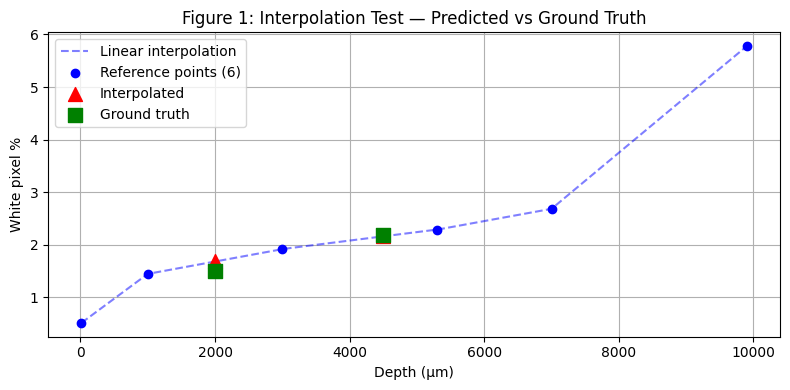

In [3]:
# Reference images and depths (same as main_example.py)
ref_files = [
    "images/MASK_SK658 Llobe ch010039.jpg",   # 15 um
    "images/MASK_SK658 Slobe ch010066.jpg",   # 1000 um
    "images/MASK_SK658 Slobe ch010147.jpg",   # 3000 um
    "images/MASK_SK658 Slobe ch010110.jpg",   # 5300 um
    "images/MASK_SK658 Slobe ch010130.jpg",   # 7000 um
    "images/MASK_SK658 Slobe ch010114.jpg",   # 9900 um
]
ref_depths = [15, 1000, 3000, 5300, 7000, 9900]

ref_pcts = [analyze_image(f)[2] for f in ref_files]

# Build linear interpolant
interp_func = interp1d(ref_depths, ref_pcts, kind='linear')

# Ground-truth test images
test_cases = [
    (2000, "images/MASK_SK658 Slobe ch010146.jpg"),
    (4500, "images/MASK_SK658 Slobe ch010134.jpg"),
]

print(f"{'Depth':>8s}  {'Interpolated':>13s}  {'Actual':>8s}  {'Error':>8s}")
print("-" * 45)
test_interp, test_actual = [], []
for depth, filepath in test_cases:
    pred = float(interp_func(depth))
    actual = analyze_image(filepath)[2]
    test_interp.append(pred)
    test_actual.append(actual)
    print(f"{depth:>8d}  {pred:>12.3f}%  {actual:>7.3f}%  {abs(pred - actual):>7.3f}%")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
x_fine = np.linspace(15, 9900, 500)
ax.plot(x_fine, interp_func(x_fine), 'b--', alpha=0.5, label='Linear interpolation')
ax.scatter(ref_depths, ref_pcts, color='blue', zorder=3, label='Reference points (6)')
ax.scatter([t[0] for t in test_cases], test_interp, color='red', marker='^', s=100, zorder=4, label='Interpolated')
ax.scatter([t[0] for t in test_cases], test_actual, color='green', marker='s', s=100, zorder=4, label='Ground truth')
ax.set_xlabel('Depth (μm)')
ax.set_ylabel('White pixel %')
ax.set_title('Figure 1: Interpolation Test — Predicted vs Ground Truth')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Figure 1** shows that linear interpolation produces reasonable estimates between reference points, but error depends heavily on spacing between known samples. With only 6 reference images spanning 15–9900 μm, large gaps (e.g., 1000–3000 μm) lead to nontrivial prediction errors because the true relationship is nonlinear.

To improve prediction accuracy, we next fit a **polynomial regression model with Ridge regularization** using all 79 available images.

### Analyzing All Images for Regression

Analyzed 78 images.


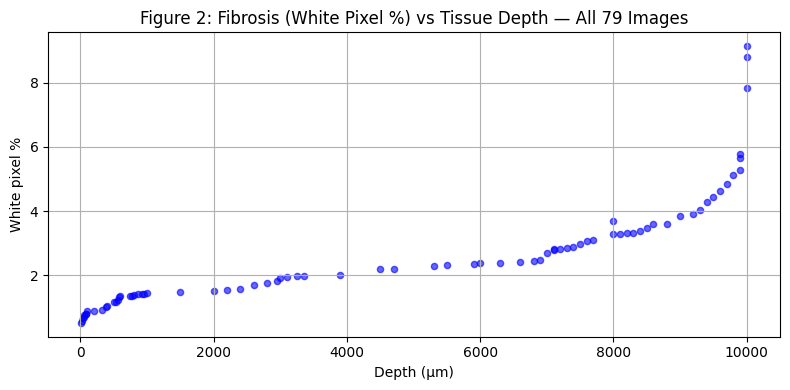

In [4]:
meta = pd.read_csv('Filenames and Depths for Students.csv')
meta.columns = ['Filename', 'Depth']

results = []
for _, row in meta.iterrows():
    w, b, pct = analyze_image(row['Filename'])
    results.append({'Filename': row['Filename'], 'Depth': row['Depth'],
                    'White': w, 'Black': b, 'White_pct': pct})

df = pd.DataFrame(results)
df.to_csv('Percent_White_Pixels_All.csv', index=False)
print(f'Analyzed {len(df)} images.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['Depth'], df['White_pct'], color='blue', alpha=0.6, s=20)
ax.set_xlabel('Depth (μm)')
ax.set_ylabel('White pixel %')
ax.set_title('Figure 2: Fibrosis (White Pixel %) vs Tissue Depth — All 79 Images')
ax.grid(True)
plt.tight_layout()
plt.show()

### Ridge Regression Model

We fit a polynomial of degree *M* with Ridge (L2) regularization parameter *λ* [3]. An 80/20 train/test split is used. **K = 5 cross-validation** on the training set searches over a grid of *M* ∈ {1,…,7} and *λ* ∈ [10⁻⁴, 10⁴] to select the hyperparameters that maximize mean R² [4].

In [5]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = df['Depth'].values.reshape(-1, 1)
y = df['White_pct'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid search
M_values = list(range(1, 8))
lambda_values = np.logspace(-4, 4, 20)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_score = -np.inf
best_M, best_lambda = None, None
cv_results = []

for M in M_values:
    for lam in lambda_values:
        fold_scores = []
        for tr_idx, val_idx in kf.split(X_train):
            poly = PolynomialFeatures(degree=M)
            X_tr_poly = poly.fit_transform(X_train[tr_idx])
            X_val_poly = poly.transform(X_train[val_idx])
            model = Ridge(alpha=lam)
            model.fit(X_tr_poly, y_train[tr_idx])
            fold_scores.append(model.score(X_val_poly, y_train[val_idx]))
        mean_r2 = np.mean(fold_scores)
        cv_results.append({'M': M, 'lambda': lam, 'mean_R2': mean_r2})
        if mean_r2 > best_score:
            best_score = mean_r2
            best_M, best_lambda = M, lam

print(f'Optimal hyperparameters: M = {best_M}, \u03bb = {best_lambda:.6f}')
print(f'Cross-validation R\u00b2 = {best_score:.4f}')

C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.52488e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.80845e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.55751e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.60503e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Optimal hyperparameters: M = 7, λ = 0.000264
Cross-validation R² = 0.9398


C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.31338e-56): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.18146e-56): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=8.9261e-56): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.32016e-56): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C

C:\Users\Aryan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.70286e-61): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


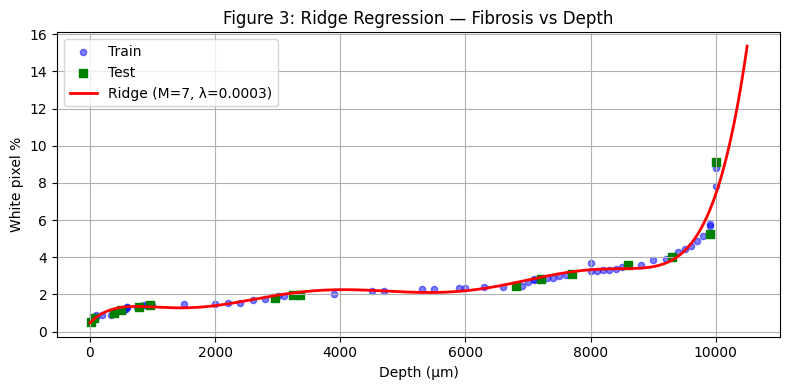

In [6]:
# Fit final model with optimal hyperparameters
poly_final = PolynomialFeatures(degree=best_M)
X_train_poly = poly_final.fit_transform(X_train)
X_test_poly = poly_final.transform(X_test)

final_model = Ridge(alpha=best_lambda)
final_model.fit(X_train_poly, y_train)

y_train_pred = final_model.predict(X_train_poly)
y_test_pred = final_model.predict(X_test_poly)

# Plot
x_plot = np.linspace(0, 10500, 500).reshape(-1, 1)
y_plot = final_model.predict(poly_final.transform(x_plot))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_train, y_train, color='blue', alpha=0.5, s=20, label='Train')
ax.scatter(X_test, y_test, color='green', marker='s', s=30, label='Test')
ax.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Ridge (M={best_M}, \u03bb={best_lambda:.4f})')
ax.set_xlabel('Depth (μm)')
ax.set_ylabel('White pixel %')
ax.set_title('Figure 3: Ridge Regression — Fibrosis vs Depth')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

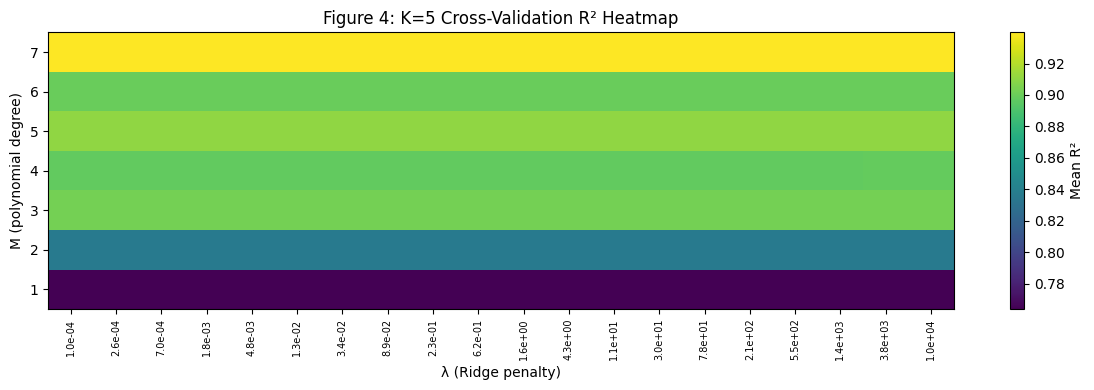

In [7]:
# Cross-validation heatmap
cv_df = pd.DataFrame(cv_results)
pivot = cv_df.pivot_table(index='M', columns='lambda', values='mean_R2')

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', origin='lower')
ax.set_xticks(range(len(lambda_values)))
ax.set_xticklabels([f'{l:.1e}' for l in lambda_values], rotation=90, fontsize=7)
ax.set_yticks(range(len(M_values)))
ax.set_yticklabels(M_values)
ax.set_xlabel('\u03bb (Ridge penalty)')
ax.set_ylabel('M (polynomial degree)')
ax.set_title('Figure 4: K=5 Cross-Validation R\u00b2 Heatmap')
plt.colorbar(im, label='Mean R\u00b2')
plt.tight_layout()
plt.show()

## Verification and Validation

**Verification:** We evaluate the Ridge regression model on the held-out 20% test set using MSE, SSE, MAE, R², and adjusted R². A residual analysis checks for systematic prediction bias.

**Validation:** Our finding that fibrosis markers increase with tissue depth is consistent with Hübner et al. (2008), who showed that quantitative pixel-based analysis of histological sections reliably tracks fibrosis severity [2]. The Ashcroft scoring system [1] similarly correlates spatial fibrosis distribution with disease progression in pulmonary tissue.

=== Model Performance ===
Metric                Train       Test
--------------------------------------
MSE                  0.0817     0.2999
SSE                  5.0670     4.7976
MAE                  0.1713     0.2924
R²                   0.9699     0.9314
Adjusted R²                     0.8715


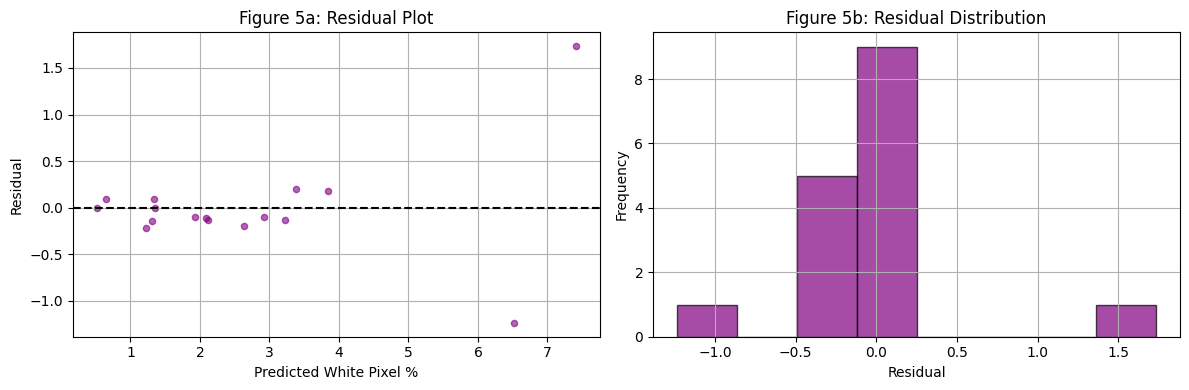

In [8]:
# Test-set metrics
n_test = len(y_test)
test_mse  = mean_squared_error(y_test, y_test_pred)
test_sse  = np.sum((y_test - y_test_pred) ** 2)
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)
adj_r2    = 1 - (1 - test_r2) * (n_test - 1) / (n_test - best_M - 1)

train_mse = mean_squared_error(y_train, y_train_pred)
train_r2  = r2_score(y_train, y_train_pred)

print('=== Model Performance ===')
print(f"{'Metric':<16s} {'Train':>10s} {'Test':>10s}")
print('-' * 38)
print(f"{'MSE':<16s} {train_mse:>10.4f} {test_mse:>10.4f}")
print(f"{'SSE':<16s} {np.sum((y_train - y_train_pred)**2):>10.4f} {test_sse:>10.4f}")
print(f"{'MAE':<16s} {mean_absolute_error(y_train, y_train_pred):>10.4f} {test_mae:>10.4f}")
print(f"{'R\u00b2':<16s} {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"{'Adjusted R\u00b2':<16s} {'':>10s} {adj_r2:>10.4f}")

# Residual plots
residuals = y_test - y_test_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test_pred, residuals, color='purple', alpha=0.6, s=20)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted White Pixel %')
axes[0].set_ylabel('Residual')
axes[0].set_title('Figure 5a: Residual Plot')
axes[0].grid(True)

axes[1].hist(residuals, bins=8, color='purple', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Figure 5b: Residual Distribution')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References

1. Ashcroft T, Simpson JM, Timbrell V. Simple method of estimating severity of pulmonary fibrosis on a numerical scale. *J Clin Pathol*. 1988;41(4):467–470.
2. Hübner RH, Gitter W, El Mokhtari NE, et al. Standardized quantification of pulmonary fibrosis in histological samples. *BioTechniques*. 2008;44(4):507–517.
3. Hoerl AE, Kennard RW. Ridge Regression: Biased Estimation for Nonorthogonal Problems. *Technometrics*. 1970;12(1):55–67.
4. James G, Witten D, Hastie T, Tibshirani R. *An Introduction to Statistical Learning*. Springer; 2013.
5. Unpublished data collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine.